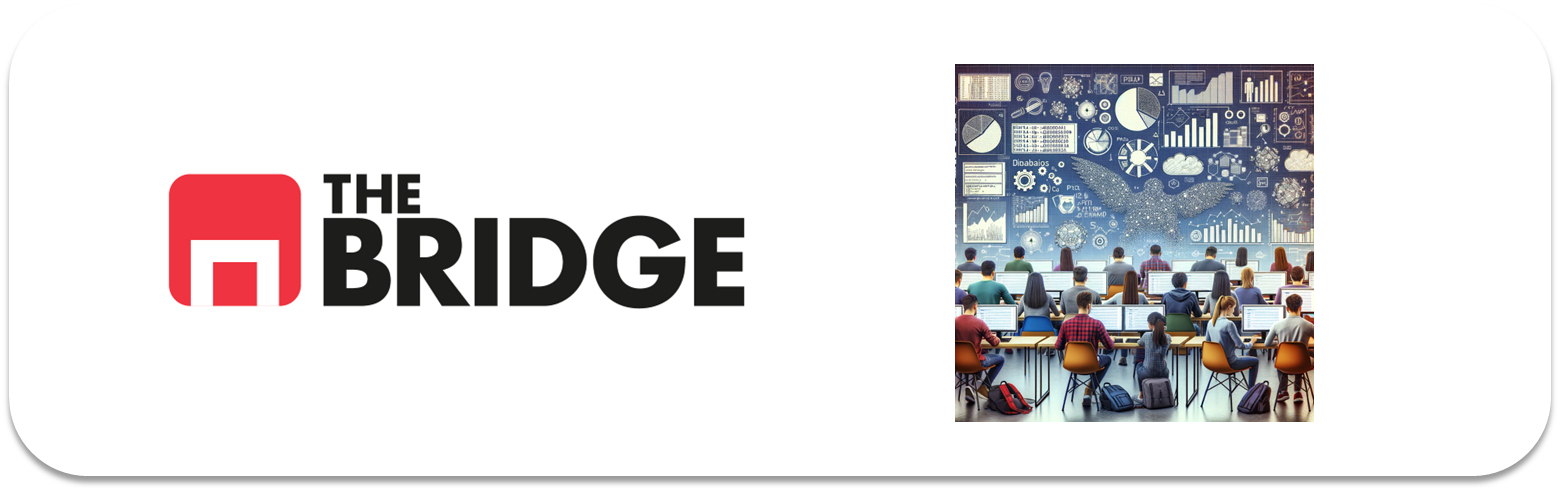

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

pd.options.mode.copy_on_write = True

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



### Paso 1: Cargar dataset

In [18]:
df = pd.read_csv("./data/titanic.csv")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


### Paso 2-3: Target y exclusión de variables

In [20]:
target = "survived"
excluidas = ["embark_town", "alive", "class", "adult_male"]

df[target].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Paso 2-4: Limpieza de deck y estratificación

In [21]:
# Rellenar nulos en deck con categoría "UNK"
df_deck = df.copy()
df_deck["deck"] = df_deck.deck.fillna("UNK")
# Eliminar nulos en embarked para poder estratificar
df_deck = df_deck.dropna(subset="embarked")
# Features base (sin deck inicialmente)
features_base = [col for col in df_deck.columns if col not in excluidas]
features_base.remove("deck")
features_base_deck = [col for col in df_deck.columns if col not in excluidas]
print("Features base:", features_base)

Features base: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'alone']


### Paso 4: Train-Test Split estratificado

In [22]:
train_set, test_set = train_test_split(df_deck, test_size=0.2, stratify=df_deck["embarked"], random_state=42)

print("Train embarked distribution:")
print(train_set.embarked.value_counts(normalize=True))
print("\nTest embarked distribution:")
print(test_set.embarked.value_counts(normalize=True))

Train embarked distribution:
embarked
S    0.724332
C    0.188467
Q    0.087201
Name: proportion, dtype: float64

Test embarked distribution:
embarked
S    0.724719
C    0.191011
Q    0.084270
Name: proportion, dtype: float64


### Paso 6: Imputación de nulos

In [23]:
# Imputar edad por mediana según genero/rol
es_hombre = train_set.who == "man"
es_mujer = train_set.who == "woman"
es_child = train_set.who == "child"
median_man = train_set[es_hombre]["age"].median()
median_woman = train_set[es_mujer]["age"].median()
median_child = train_set[es_child]["age"].median()
es_nulo = train_set.age.isna()
es_nulo_test = test_set.age.isna()

# Imputar en train
train_set.loc[es_hombre & es_nulo, "age"] = median_man
train_set.loc[es_mujer & es_nulo, "age"] = median_woman
train_set.loc[es_child & es_nulo, "age"] = median_child

# Imputar en test
test_set.loc[(test_set.who == "man") & es_nulo_test, "age"] = median_man
test_set.loc[(test_set.who == "woman") & es_nulo_test, "age"] = median_woman
test_set.loc[(test_set.who == "child") & es_nulo_test, "age"] = median_child

print("Train sin nulos:", train_set.info())
print("\nTest sin nulos:", test_set.info())

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 46 to 253
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     711 non-null    int64  
 1   pclass       711 non-null    int64  
 2   sex          711 non-null    object 
 3   age          711 non-null    float64
 4   sibsp        711 non-null    int64  
 5   parch        711 non-null    int64  
 6   fare         711 non-null    float64
 7   embarked     711 non-null    object 
 8   class        711 non-null    object 
 9   who          711 non-null    object 
 10  adult_male   711 non-null    bool   
 11  deck         711 non-null    object 
 12  embark_town  711 non-null    object 
 13  alive        711 non-null    object 
 14  alone        711 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 79.2+ KB
Train sin nulos: None
<class 'pandas.core.frame.DataFrame'>
Index: 178 entries, 223 to 142
Data columns (total 15

### Paso 7: Mini-EDA y selección de features

In [24]:
# Distribución del target
print("Target distribution (train):")
print(train_set[target].value_counts(normalize=True))
# Features numéricas
features_num = ["fare", "age", "sibsp"]

# Features categóricas
features_cat = ["pclass", "sex", "embarked", "alone", "who", "deck"]

# Crear variable binaria para deck (conocido o desconocido)
train_set["deck_informed"] = train_set.deck != "UNK"
test_set["deck_informed"] = test_set.deck != "UNK"
features_cat_updated = ["pclass", "sex", "embarked", "alone", "who", "deck_informed"]
print("\nFeatures numéricos:", features_num)
print("Features categóricos:", features_cat_updated)

Target distribution (train):
survived
0    0.618847
1    0.381153
Name: proportion, dtype: float64

Features numéricos: ['fare', 'age', 'sibsp']
Features categóricos: ['pclass', 'sex', 'embarked', 'alone', 'who', 'deck_informed']


### Paso 8: Tratamiento de variables

In [25]:
# Transformar numéricas: aplicar raíz cuadrada a fare
train_set["fare"] = np.sqrt(train_set["fare"])
test_set["fare"] = np.sqrt(test_set["fare"])

# Codificar categóricas con OrdinalEncoder
categories = [["female", "male"], ["S", "C", "Q"], ["child", "woman", "man"]]
encoder = OrdinalEncoder(categories=categories)
train_set[["sex", "embarked", "who"]] = encoder.fit_transform(train_set[["sex", "embarked", "who"]])
test_set[["sex", "embarked", "who"]] = encoder.transform(test_set[["sex", "embarked", "who"]])
print("Variables transformadas:")
print(train_set[features_num + features_cat_updated].head())

Variables transformadas:
         fare   age  sibsp  pclass  sex  embarked  alone  who  deck_informed
46   3.937004  30.0      1       3  1.0       2.0  False  2.0          False
230  9.136465  35.0      1       1  0.0       0.0  False  1.0           True
657  3.937004  32.0      1       3  0.0       2.0  False  1.0          False
888  4.842520  30.0      1       3  0.0       0.0  False  1.0          False
809  7.286975  33.0      1       1  0.0       0.0  False  1.0           True


### Paso 8b: Escalado de numéricas

In [26]:
# Escalar variables numéricas
scaler = StandardScaler()
train_set[features_num] = scaler.fit_transform(train_set[features_num])
test_set[features_num] = scaler.transform(test_set[features_num])
print("Scaled train stats:")
print(train_set[features_num].describe())

Scaled train stats:
               fare           age         sibsp
count  7.110000e+02  7.110000e+02  7.110000e+02
mean   2.748231e-17  9.993569e-17 -3.497749e-17
std    1.000704e+00  1.000704e+00  1.000704e+00
min   -1.616518e+00 -2.232200e+00 -5.091491e-01
25%   -6.670619e-01 -5.958321e-01 -5.091491e-01
50%   -3.522452e-01  1.790165e-02 -5.091491e-01
75%    2.429585e-01  4.014852e-01  5.105833e-01
max    6.031542e+00  3.853737e+00  7.648711e+00


### Paso 9: Construir modelo de Regresión Logística

=== MODEL 1: Categóricas principales ===
TRAIN METRICS:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       440
           1       0.84      0.58      0.68       271

    accuracy                           0.80       711
   macro avg       0.81      0.75      0.77       711
weighted avg       0.80      0.80      0.79       711



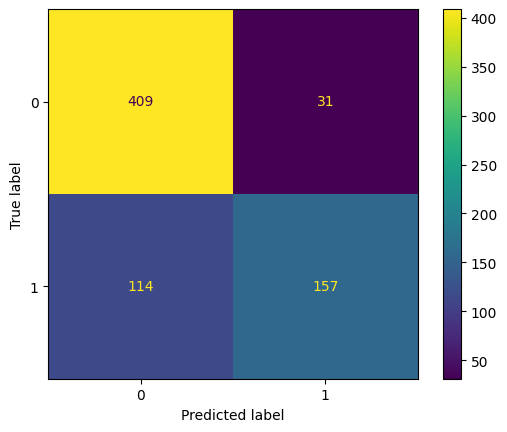

In [27]:
# Definir función para evaluar modelos
def metrics_titanic(model, X, y_target):
    y_pred = model.predict(X)
    ConfusionMatrixDisplay.from_predictions(y_target, y_pred)
    print(classification_report(y_target, y_pred))

# Modelo 1: Solo categóricas principales
features_set_cat_1 = ["pclass", "who"]
X_train_1 = train_set[features_set_cat_1]
y_train = train_set[target]
X_test_1 = test_set[features_set_cat_1]
y_test = test_set[target]
log_class_1 = LogisticRegression(max_iter=10000)
log_class_1.fit(X_train_1, y_train)

print("=== MODEL 1: Categóricas principales ===")
print("TRAIN METRICS:")
metrics_titanic(log_class_1, X_train_1, y_train)

TEST METRICS:
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       109
           1       0.78      0.57      0.66        69

    accuracy                           0.77       178
   macro avg       0.77      0.73      0.74       178
weighted avg       0.77      0.77      0.76       178



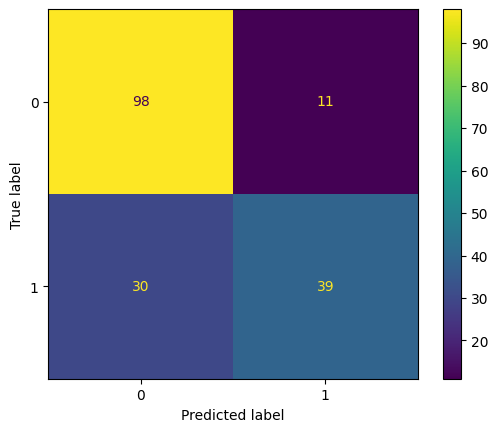

In [28]:
print("TEST METRICS:")
metrics_titanic(log_class_1, X_test_1, y_test)

### Curva ROC - Modelo 1

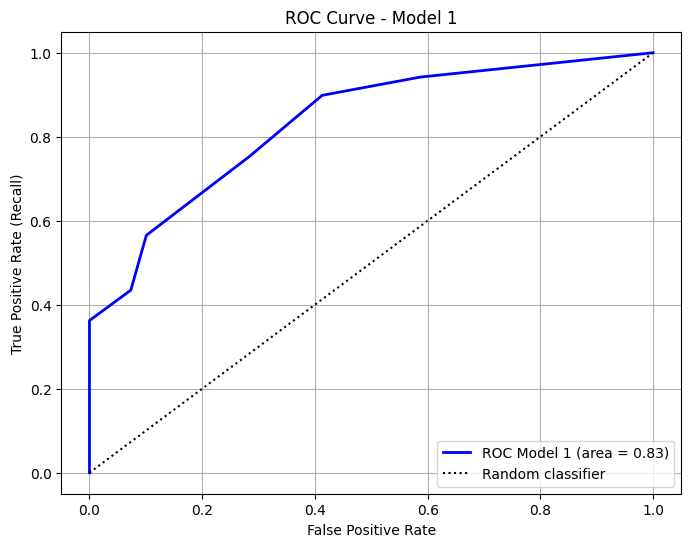

In [29]:
# Curva ROC del Modelo 1
scores_1 = log_class_1.predict_proba(X_test_1)
fpr_1, tpr_1, _ = roc_curve(y_test, scores_1[:, 1])
roc_auc_1 = auc(fpr_1, tpr_1)

plt.figure(figsize=(8, 6))
plt.plot(fpr_1, tpr_1, linewidth=2, color="blue", label=f"ROC Model 1 (area = {roc_auc_1:.2f})")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title("ROC Curve - Model 1")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Modelo 2: Todas las categóricas

=== MODEL 2: Todas categóricas ===
TRAIN METRICS:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       440
           1       0.80      0.71      0.75       271

    accuracy                           0.82       711
   macro avg       0.82      0.80      0.81       711
weighted avg       0.82      0.82      0.82       711



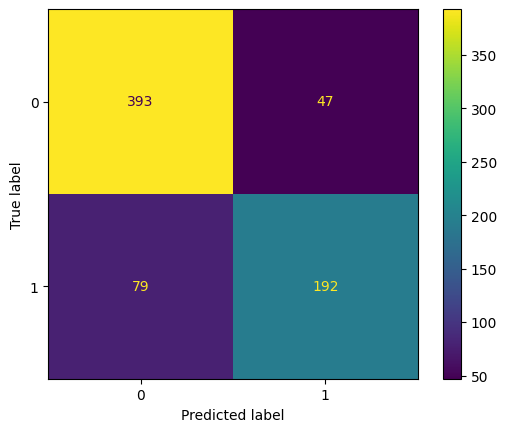

In [30]:
# Modelo 2: Todas las categóricas
X_train_2 = train_set[features_cat_updated]
X_test_2 = test_set[features_cat_updated]
log_class_2 = LogisticRegression(max_iter=10000)
log_class_2.fit(X_train_2, y_train)
print("=== MODEL 2: Todas categóricas ===")
print("TRAIN METRICS:")
metrics_titanic(log_class_2, X_train_2, y_train)

TEST METRICS:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       109
           1       0.77      0.67      0.71        69

    accuracy                           0.79       178
   macro avg       0.79      0.77      0.78       178
weighted avg       0.79      0.79      0.79       178



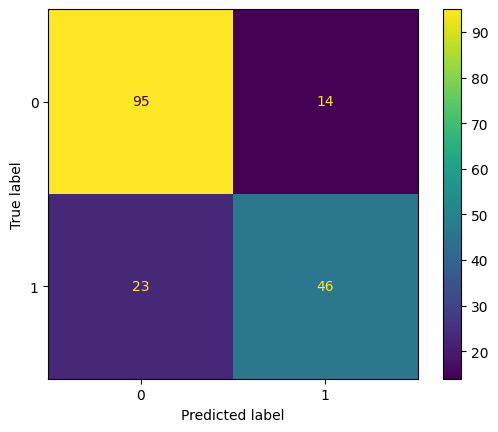

In [31]:
print("TEST METRICS:")
metrics_titanic(log_class_2, X_test_2, y_test)

### Modelo 3: Categóricas + Numéricas

=== MODEL 3: Categóricas + Numéricas ===
TRAIN METRICS:
              precision    recall  f1-score   support

           0       0.84      0.88      0.85       440
           1       0.78      0.72      0.75       271

    accuracy                           0.82       711
   macro avg       0.81      0.80      0.80       711
weighted avg       0.81      0.82      0.81       711



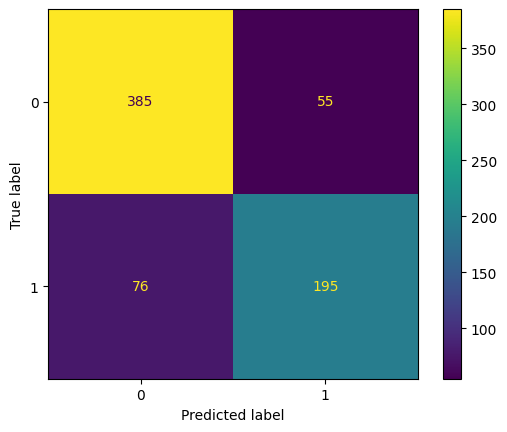

In [32]:
# Modelo 3: Categóricas + Numéricas
X_train_3 = train_set[features_cat_updated + features_num]
X_test_3 = test_set[features_cat_updated + features_num]
log_class_3 = LogisticRegression(max_iter=10000)
log_class_3.fit(X_train_3, y_train)
print("=== MODEL 3: Categóricas + Numéricas ===")
print("TRAIN METRICS:")
metrics_titanic(log_class_3, X_train_3, y_train)

TEST METRICS:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       109
           1       0.73      0.71      0.72        69

    accuracy                           0.79       178
   macro avg       0.78      0.77      0.77       178
weighted avg       0.79      0.79      0.79       178



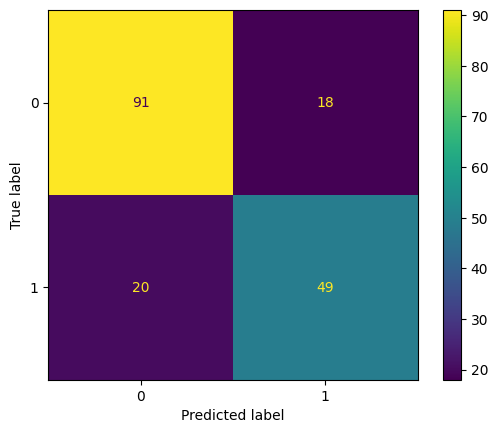

In [33]:
print("TEST METRICS:")
metrics_titanic(log_class_3, X_test_3, y_test)

### Curva ROC - Modelo 3

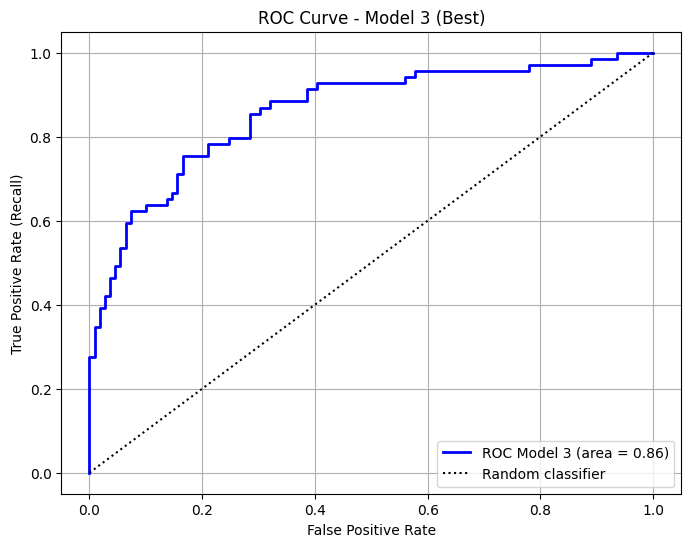

In [34]:
# Curva ROC del Modelo 3 (mejor)
scores_3 = log_class_3.predict_proba(X_test_3)
fpr_3, tpr_3, _ = roc_curve(y_test, scores_3[:, 1])
roc_auc_3 = auc(fpr_3, tpr_3)
plt.figure(figsize=(8, 6))
plt.plot(fpr_3, tpr_3, linewidth=2, color="blue", label=f"ROC Model 3 (area = {roc_auc_3:.2f})")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title("ROC Curve - Model 3 (Best)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### EXTRA: Predicción de probabilidad (hombre 30-40 años, Southampton, segunda clase, solo, sin pagó)

In [35]:
# Crear datos base para predicción
data_base = {
    "pclass": 2,
    "embarked": 0,  # Southampton = S (coded as 0)
    "alone": True,
    "fare": 0,
    "who": 2,  # man
    "deck_informed": False,
    "sibsp": 0,
    "sex": 1  # male (coded as 1)
}

probs = []
for age in range(30, 41):
    data = data_base.copy()
    data["age"] = age
    X_man = pd.DataFrame([data])
    
    # Escalar features numéricas
    X_man[features_num] = scaler.transform(X_man[features_num])
    
    # Predicción
    prob_dead, prob_surv = log_class_3.predict_proba(X_man[features_cat_updated + features_num])[0]
    probs.append(prob_surv)
    
mean_prob = np.mean(probs)
print(f"Probabilidad media de supervivencia (hombre 30-40 años, Southampton, segundo clase): {mean_prob:.2%}")

Probabilidad media de supervivencia (hombre 30-40 años, Southampton, segundo clase): 13.87%


### EXTRA: Adaptación a problema multiclase (predicción de clase del viajero)

In [36]:
# Cambiar target a pclass (multiclase)
new_target = "pclass"
new_features = features_cat_updated + features_num + [target]
new_features.remove(new_target)

print("Features para multiclase:", new_features)

X_train_multi = train_set[new_features]
y_train_multi = train_set[new_target]

X_test_multi = test_set[new_features]
y_test_multi = test_set[new_target]

log_class_multi = LogisticRegression(max_iter=10000)
log_class_multi.fit(X_train_multi, y_train_multi)

print("\n=== MULTICLASS MODEL ===")
print("TRAIN METRICS:")
print(classification_report(y_train_multi, log_class_multi.predict(X_train_multi)))

print("\nTEST METRICS:")
print(classification_report(y_test_multi, log_class_multi.predict(X_test_multi)))

Features para multiclase: ['sex', 'embarked', 'alone', 'who', 'deck_informed', 'fare', 'age', 'sibsp', 'survived']

=== MULTICLASS MODEL ===
TRAIN METRICS:
              precision    recall  f1-score   support

           1       0.92      0.90      0.91       163
           2       0.78      0.43      0.55       143
           3       0.82      0.95      0.88       405

    accuracy                           0.84       711
   macro avg       0.84      0.76      0.78       711
weighted avg       0.83      0.84      0.82       711


TEST METRICS:
              precision    recall  f1-score   support

           1       0.90      0.92      0.91        51
           2       0.61      0.27      0.37        41
           3       0.74      0.93      0.82        86

    accuracy                           0.78       178
   macro avg       0.75      0.71      0.70       178
weighted avg       0.76      0.78      0.75       178

